In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Library primitives only — general loaders, filters, plotters, styling.
# Section-specific configs (group keys, color maps, suptitles) live in the
# cells that use them.
from lora_playground.plot_utils import (
    DIVERGE_THRESHOLD, OPTIM_COLORS,
    has_runs, load_sweep, max_loss, merge_runs, parse_flag,
    best_run, baseline_overlay,
    plot_leaderboard_by_rank, two_panel_sweep_figure,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

In [3]:
# Section-specific palettes (general OPTIM_COLORS imported from library).
M_COLORS = {1: plt.cm.plasma(0.15), 4: plt.cm.plasma(0.50), 16: plt.cm.plasma(0.85)}
MODE_COLORS = {"svd_step_oracle": "#ff7f0e", "svd_cumulative_oracle": "#2ca02c"}
MUON_VARIANT_COLORS = {
    "muon":              "#e377c2",
    "muon+m=4":          "#d62728",
    "muon+m=16":         "#8c2d04",
    "muon+ns=0":         "#bababa",
    "product-muon":      "#1f77b4",
    "product-muon+m=4":  "#0d3d66",
    "adam-muon":         "#2ca02c",
    "adam-muon+m=4":     "#0d4f0d",
}

## H4 *-Post + H5 matrix-Adam + Polar-Product investigation

Cross-investigation leaderboard for the lin/scaled-lora extensions:
- **`*-post`**: Adam(m,v) on raw ∇, then geometric solve (Sylvester / Gram) on Adam's step. RMS-aligned step magnitude.
- **`*-matrix`**: per-pair scalar v̂ instead of per-coord — preserves direction by sacrificing Adam's per-coord adaptation.
- **`adam-polar-product-lora`**: theory's closed-form spectral-product update (lemma at `docs/theory/main.tex` line 622-660). Polar (NS) sandwiched between two factors of S^{-1/2}, fed Adam's denoised direction.

See `docs/notes/optimizer_synthesis.md` for the cross-investigation synthesis.

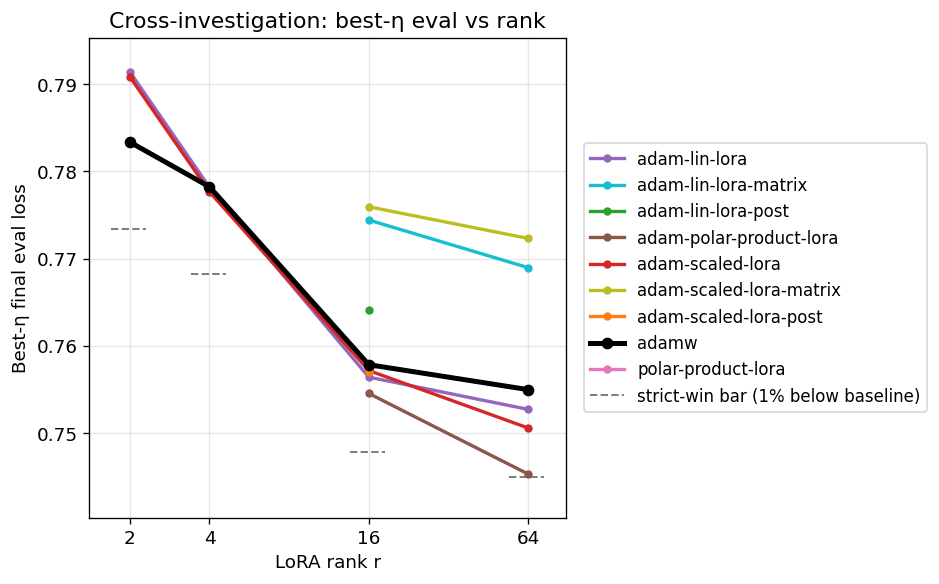

In [4]:
# Cross-investigation extensions: load + per-rank best-η + leaderboard.
EXT_SOURCES = (
    "polar_product_eta1e3_2k", "polar_product_2k",
    "h4_post_rmsalign_2k", "h4_post_2k",
    "h5_matrix_r64_2k", "h5_matrix_2k",
    "r64_eta_sweep_extension_2k",
    "h3_rsweep_2k",
    "optim_compare_high_eta_2k", "lr_sweep_2k",
)
EXT_OPTIMIZERS = {
    "adamw",
    "adam-lin-lora", "adam-scaled-lora",
    "adam-lin-lora-post", "adam-scaled-lora-post",
    "adam-lin-lora-matrix", "adam-scaled-lora-matrix",
    "polar-product-lora", "adam-polar-product-lora",
}

ext_runs = merge_runs(
    EXT_SOURCES,
    key_fn=lambda c: (c["optimizer"], float(c["lr"]), int(c.get("lora_r", 16))),
    filter_fn=lambda c: c["optimizer"] in EXT_OPTIMIZERS,
    cfg_postprocess=lambda c, g: c.update(_lora_r=int(c.get("lora_r", 16))),
)

# Best-η per (optimizer, r) at step 2000
best = {}
for cfg, evs in ext_runs:
    if evs[-1]["step"] < 2000:
        continue
    k = (cfg["optimizer"], cfg["_lora_r"])
    fl = evs[-1]["eval_loss"]
    if k not in best or fl < best[k][2]:
        best[k] = (cfg, evs, fl)
adamw_floor = {r: best[("adamw", r)][2] for (opt, r) in best if opt == "adamw"}

plot_leaderboard_by_rank(best, baseline_optimizer="adamw", color_map=OPTIM_COLORS,
                          suptitle="Cross-investigation: best-η eval vs rank")
plt.show()

### r=16 — extensions vs AdamW r=16

  [filtered diverged] adam-scaled-lora         η=1e-02 max=2.269 final=1.665
  [filtered diverged] adamw                    η=1e-02 max=9.009 final=6.937


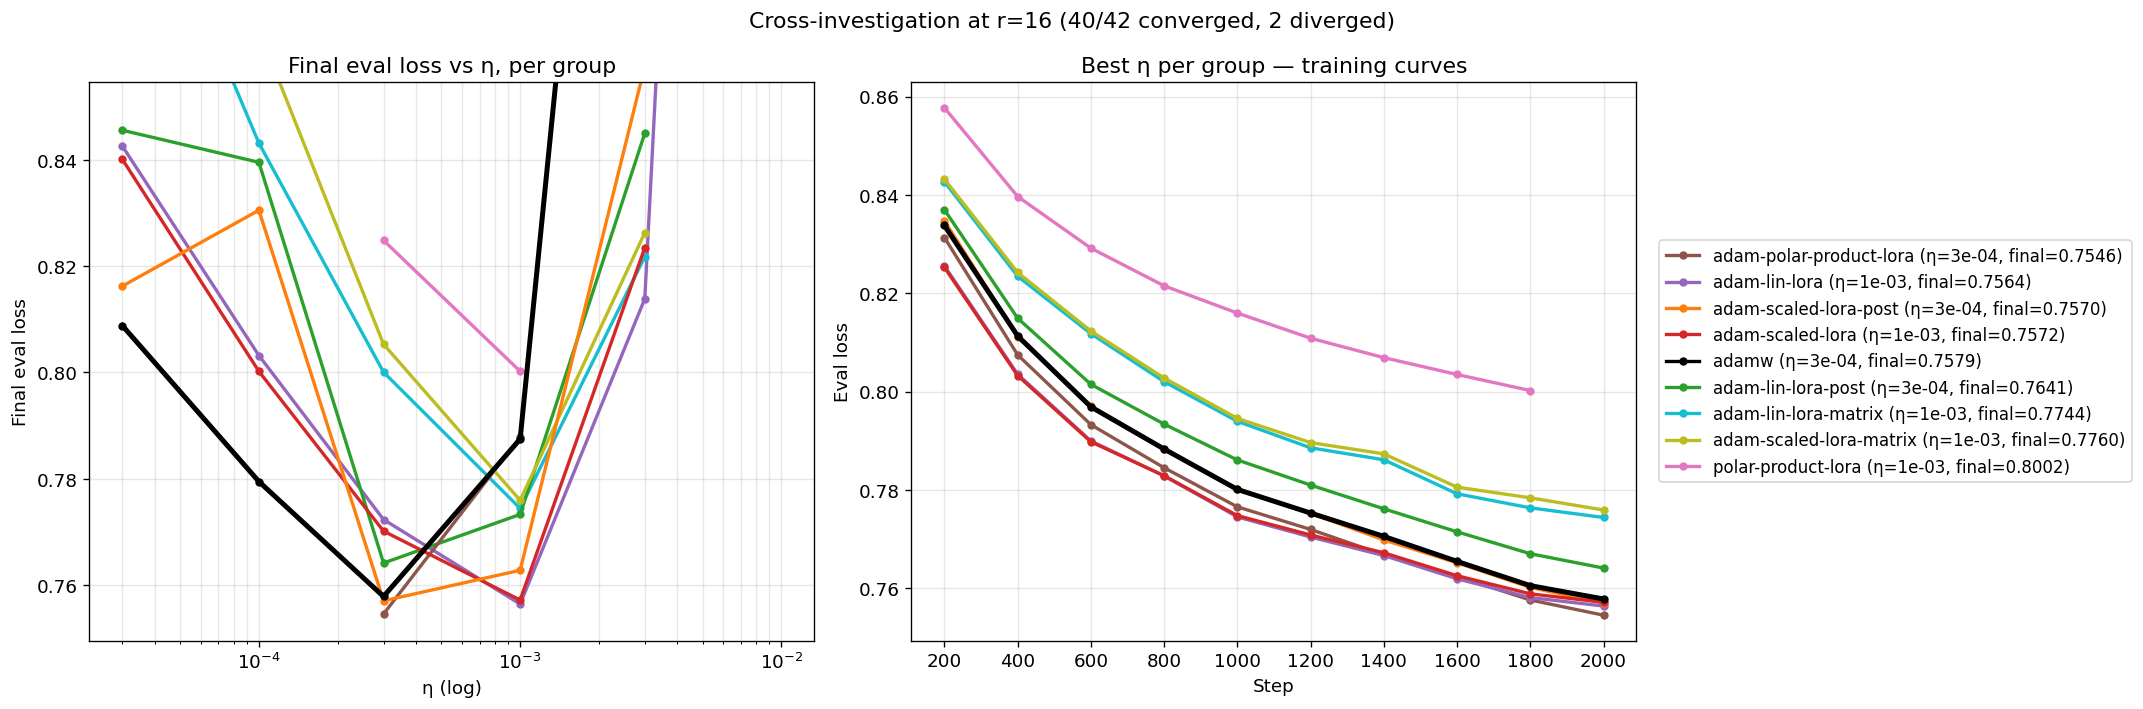

In [5]:
floor = adamw_floor[16]
runs_at_r = [(c, e) for c, e in ext_runs if c["_lora_r"] == 16]
two_panel_sweep_figure(
    runs_at_r,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    suptitle="Cross-investigation at r=16",
    hlines=[(f"strict-win bar = {floor - 0.01:.4f}  (1% below AdamW r=16 floor {floor:.4f})",
             floor - 0.01, "grey")],
    label_fn=lambda c: f"{c['optimizer']:<24s} η={c['lr']:.0e}",
)
plt.show()

### r=64 — extensions vs AdamW r=64

⚠ **η range is currently pinned at the lower boundary.** All r=64 sweeps
(adamw, adam-lin-lora, adam-scaled-lora, adam-polar-product-lora) have their
best η at 3e-4 — the smallest η in the sweep. We don't yet know whether
η=1e-4 or η=3e-5 would do better; the comparison is bottom-pinned. A cleaner
r=64 lr-sweep extension is queued separately.

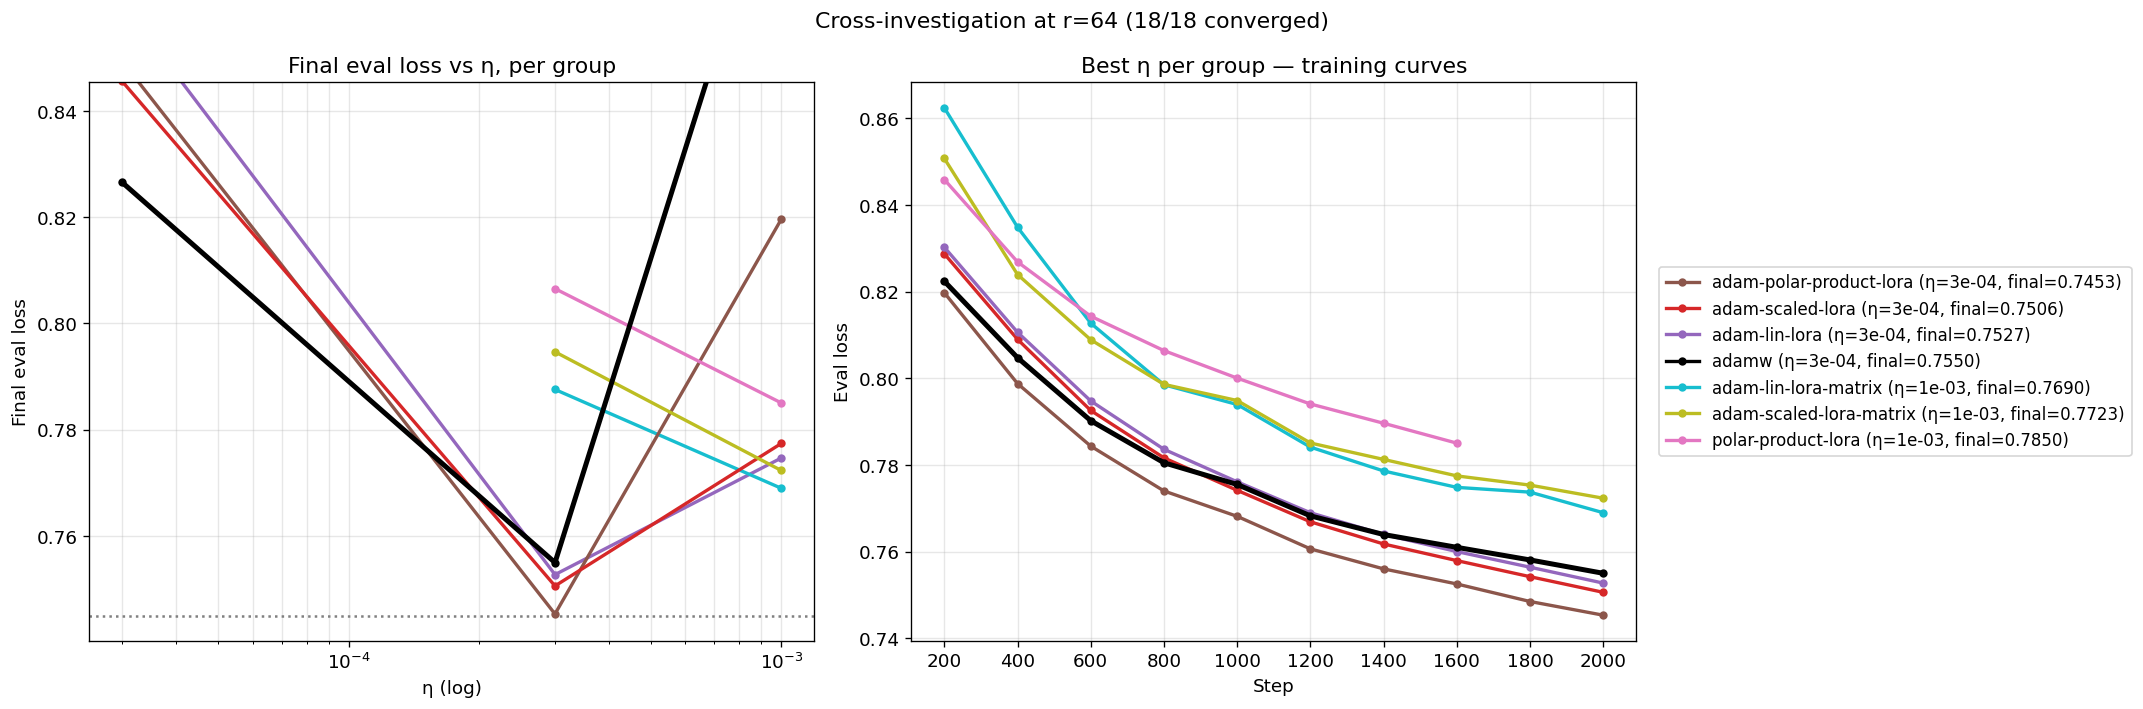

In [6]:
floor = adamw_floor[64]
runs_at_r = [(c, e) for c, e in ext_runs if c["_lora_r"] == 64]
two_panel_sweep_figure(
    runs_at_r,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    suptitle="Cross-investigation at r=64",
    hlines=[(f"strict-win bar = {floor - 0.01:.4f}  (1% below AdamW r=64 floor {floor:.4f})",
             floor - 0.01, "grey")],
    label_fn=lambda c: f"{c['optimizer']:<24s} η={c['lr']:.0e}",
)
plt.show()

## All optimizers — η sweep, r=16, 2000 steps

η ∈ {3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2}, seed=0. All optimizers compared on the
same axis. Sources merged across `lr_sweep_2k`, `optim_compare_high_eta_2k`,
`muon_lowlr_2k`, `new_optimizers_high_eta_2k`, `new_optimizers_2k`, `psi_lora_2k`,
`galore_fixed_2k`. Diverged runs (max eval > 1.5) filtered.

**Honest naming.** What we previously called `psi-lora` was just diagonal D_V/D_U scaling —
renamed to **`diag-scaled-lora`**. `kfac-lora` was a custom variant (r×r gradient outer
products) — renamed to **`kron-grad-lora`**. The `psi-lora` slot now points to the paper
Algorithm 3 port (F-LoRSUM proximal subspace iteration with K-FAC metrics + low-rank
momentum, eq. 14 of arXiv 2602.16456).

**Muon-LoRA NS bug fix.** Original `_newton_schulz` re-multiplied output by input Frobenius
norm, breaking scale-invariance — combined with PEFT's B=0 init the updates collapsed and
η was nearly irrelevant. Fixed: NS output now has Frobenius norm √r regardless of input.

**GaLore** (`galore-adamw`) uses a different training mode — full dense weights with rank-r
gradient projection refreshed every 200 steps. Included for direct comparison; it's ~3× slower
per step than LoRA-mode optimizers due to backprop through full weights.

In [7]:
# Sources, in priority order for (optimizer, η) deduplication. Earlier groups
# override later ones. Comment lines describe each group's contribution.
SOURCE_GROUPS = (
    "psi_lora_2k",                # PSI-LoRA Algorithm 3 port
    "muon_lowlr_2k",              # bug-fixed muon at low η
    "boundary_extend3_2k",        # lin/scaled at η ∈ {10, 30}
    "boundary_extend2_2k",        # diag/lin/scaled at η ∈ {1, 3}
    "boundary_extend_2k",         # diag/lin/scaled at η ∈ {3e-2, 1e-1, 3e-1}
    "new_optimizers_high_eta_2k", # diag/kron/muon at η ∈ {3e-3, 1e-2, 3e-2}
    "galore_fixed_2k",            # GaLore matched to ~/GaLore (post-fix)
    "optim_compare_high_eta_2k",  # original 5 optimizers at η ∈ {3e-3, 1e-2}
    "lr_sweep_2k",                # original 5 optimizers at low η
    "new_optimizers_2k",          # legacy psi/kfac at low η (renamed via alias)
    "galore_2k",                  # buggy GaLore (superseded by galore_fixed)
)

# Historical logs labeled "psi-lora"/"kfac-lora" were the diagonal-scaled /
# Kron-grad ablations, NOT the paper algorithms. Alias them to honest names
# so the legend reflects what was computed. The "psi-lora" slot is reserved
# for runs from psi_lora_2k (the actual Algorithm 3 port).
RENAME_ALIAS = {"psi-lora": "diag-scaled-lora", "kfac-lora": "kron-grad-lora"}
NEW_PSI_GROUPS = {"psi_lora_2k"}


def _alias_optimizer(cfg, group):
    if group not in NEW_PSI_GROUPS:
        cfg["optimizer"] = RENAME_ALIAS.get(cfg["optimizer"], cfg["optimizer"])

all_runs = merge_runs(
    SOURCE_GROUPS,
    key_fn=lambda c: (c["optimizer"], float(c["lr"])),
    filter_fn=lambda c: c["optimizer"] in OPTIM_COLORS,
    cfg_postprocess=_alias_optimizer,
)

print(f"Loaded {len(all_runs)} runs across {len({c['optimizer'] for c, _ in all_runs})} optimizers")
for cfg, evs in sorted(all_runs, key=lambda x: (x[0]["optimizer"], x[0]["lr"])):
    flag = " DIVERGED" if max_loss(evs) >= DIVERGE_THRESHOLD else ""
    print(f"  {cfg['optimizer']:<18s}  η={cfg['lr']:.0e}  step={evs[-1]['step']}  "
          f"final={evs[-1]['eval_loss']:.4f}{flag}")

Loaded 77 runs across 10 optimizers
  adam-lin-lora       η=3e-05  step=2000  final=0.8426
  adam-lin-lora       η=1e-04  step=2000  final=0.8032
  adam-lin-lora       η=3e-04  step=2000  final=0.7723
  adam-lin-lora       η=1e-03  step=2000  final=0.7564
  adam-lin-lora       η=3e-03  step=2000  final=0.8139
  adam-lin-lora       η=1e-02  step=2000  final=1.3112
  adam-scaled-lora    η=3e-05  step=2000  final=0.8401
  adam-scaled-lora    η=1e-04  step=2000  final=0.8002
  adam-scaled-lora    η=3e-04  step=2000  final=0.7702
  adam-scaled-lora    η=1e-03  step=2000  final=0.7572
  adam-scaled-lora    η=3e-03  step=2000  final=0.8235
  adam-scaled-lora    η=1e-02  step=2000  final=1.6646 DIVERGED
  adamw               η=3e-05  step=2000  final=0.8088
  adamw               η=1e-04  step=2000  final=0.7795
  adamw               η=3e-04  step=2000  final=0.7579
  adamw               η=1e-03  step=2000  final=0.7875
  adamw               η=3e-03  step=2000  final=1.0223
  adamw             

  [filtered diverged] adam-scaled-lora   η=1e-02 max=2.269 final=1.665
  [filtered diverged] adamw              η=1e-02 max=9.009 final=6.937
  [filtered diverged] diag-scaled-lora   η=1e+00 max=9.292 final=6.136
  [filtered diverged] diag-scaled-lora   η=3e+00 max=12.436 final=8.034
  [filtered diverged] galore-adamw       η=1e-02 max=1.653 final=1.636
  [filtered diverged] kron-grad-lora     η=3e-02 max=9.879 final=4.922


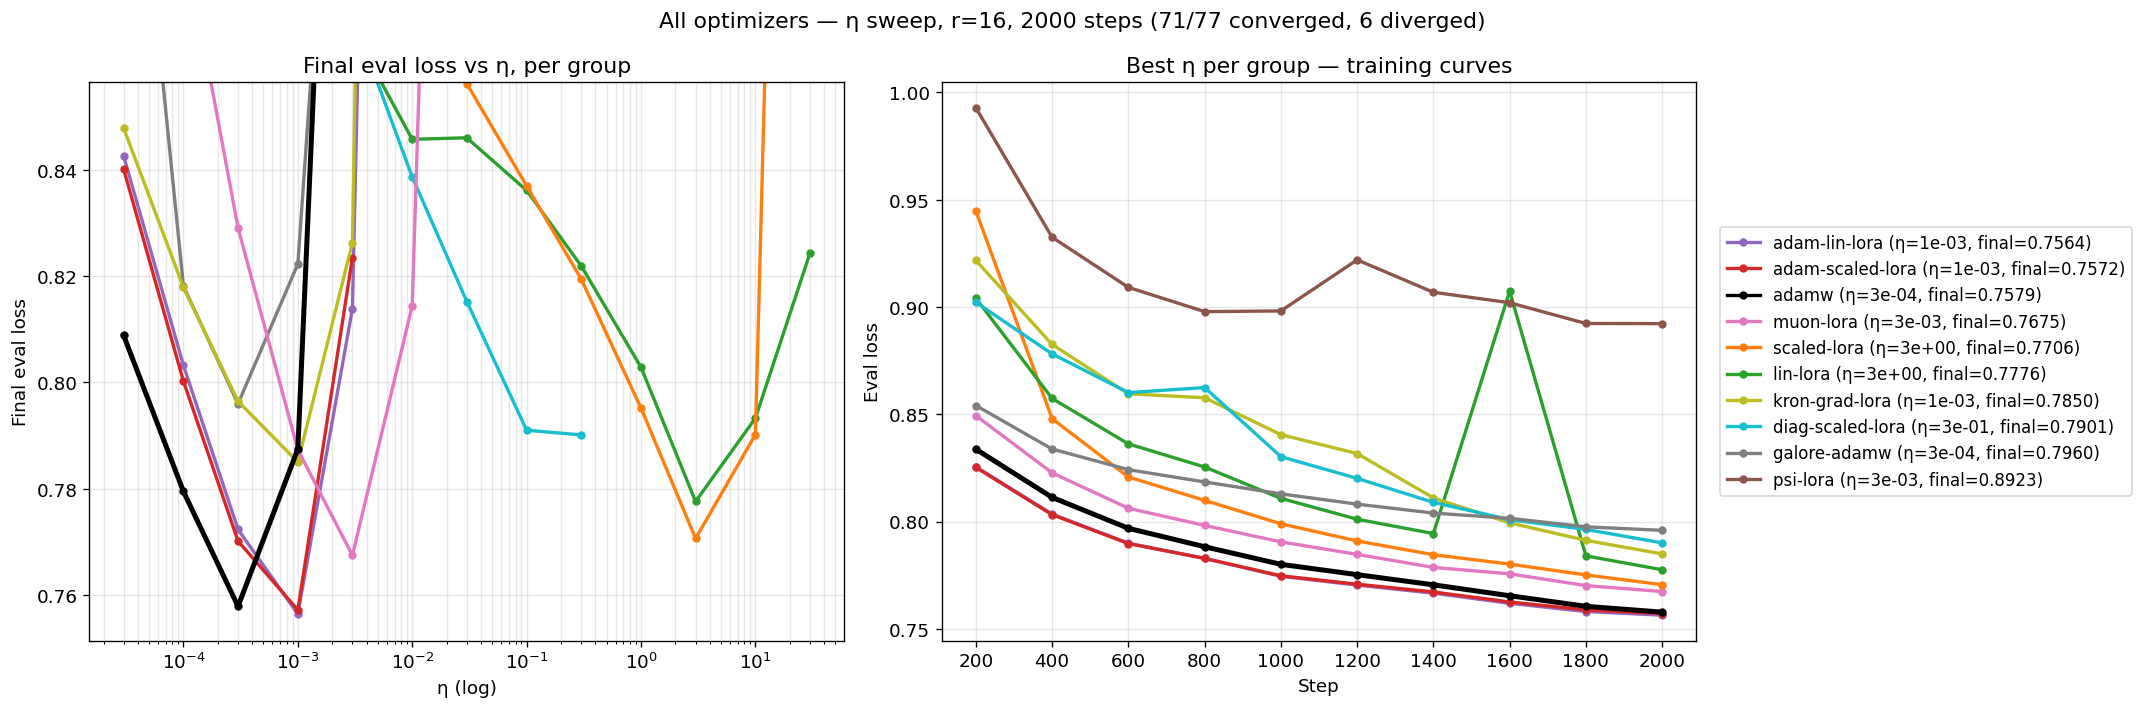

In [8]:
two_panel_sweep_figure(
    all_runs,
    group_key_fn=lambda c: c["optimizer"],
    color_map=OPTIM_COLORS,
    suptitle="All optimizers — η sweep, r=16, 2000 steps",
    label_fn=lambda c: f"{c['optimizer']:<18s} η={c['lr']:.0e}",
)
plt.show()

## Muon-LoRA variants — beat AdamW campaign

Hypothesis-driven sweep:
- **Tier 1 (`muon_loraplus_2k`)**: H1 — LoRA+ asymmetry on B's lr (m ∈ {4, 16}). Baseline m=1 reused from earlier groups.
- **Tier 2 (`muon_nsoff_2k`)**: H3 sanity — `--muon_ns_steps 0` ⇒ momentum SGD (NS disabled). If matches Muon-LoRA, the orthogonalization is irrelevant.
- **Tier 3 (`product_muon_2k`)**: H2 — `ProductMuonLoRA`, NS on the merged-direction proxy `D = (1/scale)·m_B·(AAᵀ+δI)⁻¹·A` then Sylvester-recovered. Theory: `docs/theory/main.tex` line 622+.
- **Tier 4 (`adam_muon_2k`)**: H4 — `AdamMuonLoRA`, NS on Adam's m̂/(√v̂+ε) direction.

Reference frontiers (from earlier sweeps): AdamW @ 0.7579, adam-lin-lora @ 0.7564. Goal: **strictly beat** both.

In [9]:
def _stamp_muon_meta(cfg, group):
    """Inject muon_ns_steps from --muon_ns_steps (default 5)."""
    v = parse_flag(cfg.get("command", ""), "--muon_ns_steps")
    cfg["muon_ns_steps"] = int(v) if v is not None else 5

MUON_SOURCES = (
    "muon_loraplus_lowlr_2k",      # m ∈ {4, 16} × η ∈ {1e-4, 3e-4} (extension)
    "muon_loraplus_2k",            # m ∈ {4, 16} × η ∈ {1e-3, 3e-3, 1e-2}
    "muon_nsoff_2k",               # ns_steps=0 sanity check
    "product_muon_2k",             # H2: ProductMuonLoRA
    "adam_muon_2k",                # H4: AdamMuonLoRA
    "muon_lowlr_2k",               # m=1 baseline at η ∈ {3e-5..1e-3}
    "new_optimizers_high_eta_2k",  # m=1 baseline at η ∈ {3e-3..3e-2}
)

muon_runs = merge_runs(
    MUON_SOURCES,
    key_fn=lambda c: (c["optimizer"], float(c["lr"]),
                      float(c.get("lora_plus_multiplier", 1.0)), c["muon_ns_steps"]),
    filter_fn=lambda c: c["optimizer"] in {"muon-lora", "product-muon-lora", "adam-muon-lora"},
    cfg_postprocess=_stamp_muon_meta,
)

print(f"Loaded {len(muon_runs)} Muon-family runs")
for cfg, evs in sorted(muon_runs, key=lambda x: (x[0]["optimizer"], x[0]["muon_ns_steps"],
                                                  x[0]["lora_plus_multiplier"], x[0]["lr"])):
    flag = " DIVERGED" if max_loss(evs) >= DIVERGE_THRESHOLD else ""
    print(f"  {cfg['optimizer']:<18s}  η={cfg['lr']:.0e}  "
          f"m={float(cfg['lora_plus_multiplier']):>4.1f}  "
          f"ns={cfg['muon_ns_steps']}  final={evs[-1]['eval_loss']:.4f}{flag}")

Loaded 21 Muon-family runs
  muon-lora           η=3e-04  m= 1.0  ns=0  final=1.1844
  muon-lora           η=1e-03  m= 1.0  ns=0  final=1.1658
  muon-lora           η=3e-03  m= 1.0  ns=0  final=1.0672
  muon-lora           η=1e-02  m= 1.0  ns=0  final=0.9499
  muon-lora           η=3e-05  m= 1.0  ns=5  final=1.0015
  muon-lora           η=1e-04  m= 1.0  ns=5  final=0.8842
  muon-lora           η=3e-04  m= 1.0  ns=5  final=0.8291
  muon-lora           η=1e-03  m= 1.0  ns=5  final=0.7873
  muon-lora           η=3e-03  m= 1.0  ns=5  final=0.7675
  muon-lora           η=1e-02  m= 1.0  ns=5  final=0.8144
  muon-lora           η=3e-02  m= 1.0  ns=5  final=1.1452
  muon-lora           η=1e-04  m= 4.0  ns=5  final=0.8377
  muon-lora           η=3e-04  m= 4.0  ns=5  final=0.7978
  muon-lora           η=1e-03  m= 4.0  ns=5  final=0.7674
  muon-lora           η=3e-03  m= 4.0  ns=5  final=0.7759
  muon-lora           η=1e-02  m= 4.0  ns=5  final=0.9611
  muon-lora           η=1e-04  m=16.0  ns=5  

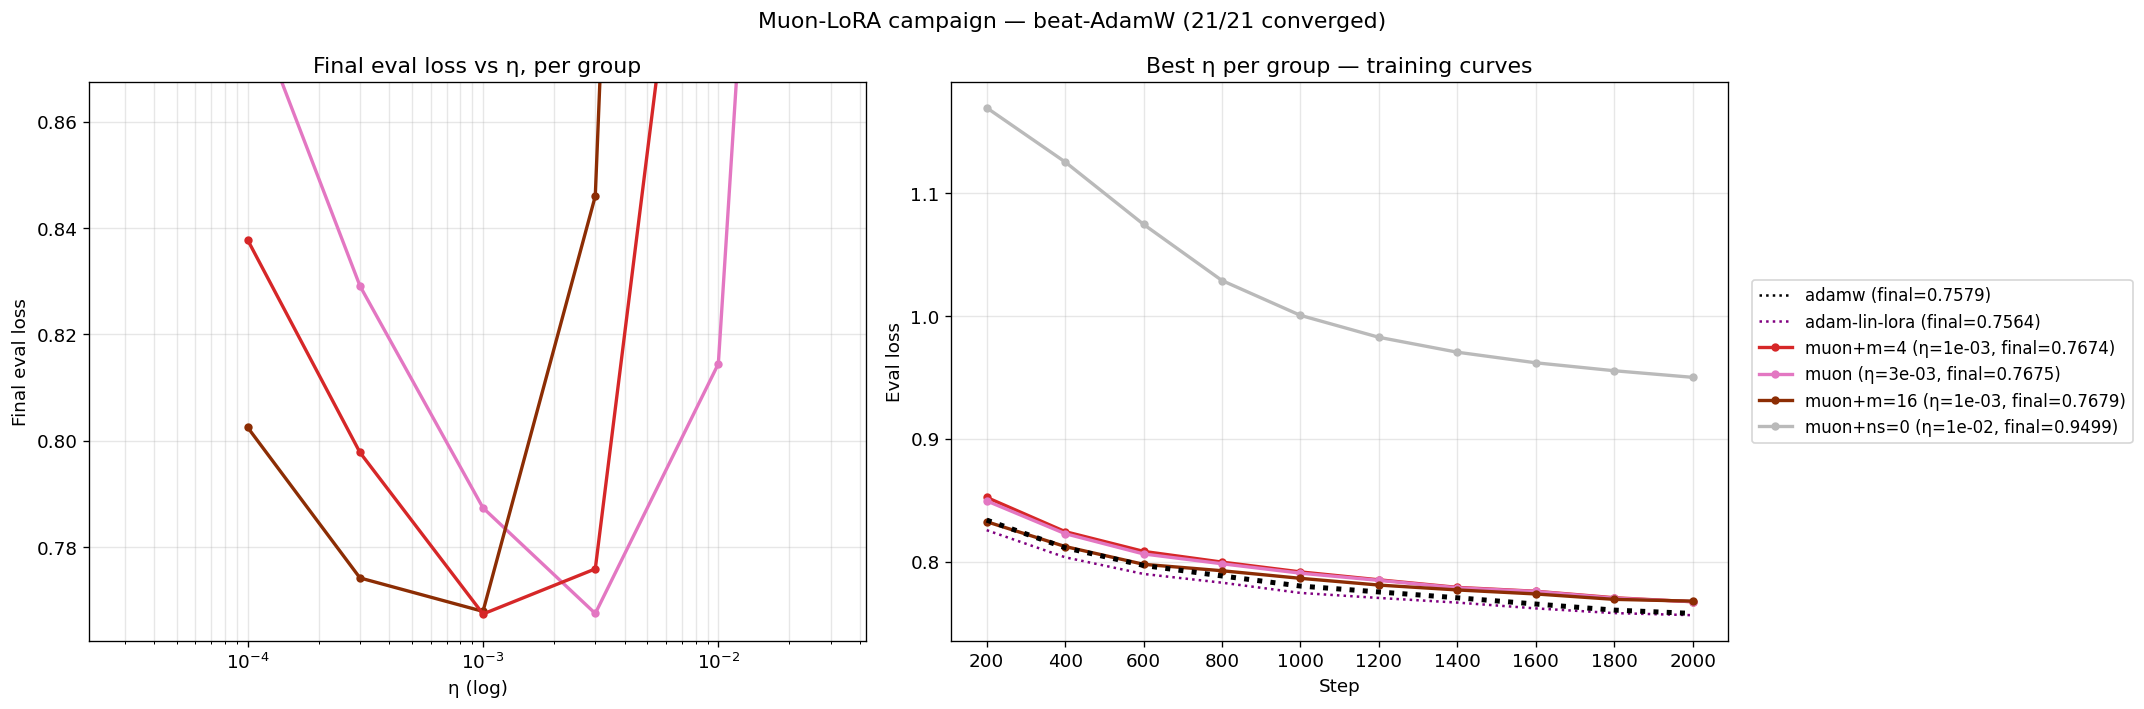

In [10]:
def _muon_variant(cfg):
    opt = cfg["optimizer"]
    m = float(cfg.get("lora_plus_multiplier", 1.0))
    ns = cfg.get("muon_ns_steps", 5)
    base = {"muon-lora": "muon", "product-muon-lora": "product-muon",
            "adam-muon-lora": "adam-muon"}[opt]
    parts = [base]
    if m != 1.0: parts.append(f"m={int(m)}")
    if ns == 0:  parts.append("ns=0")
    return "+".join(parts)

hl_a, rc_a = baseline_overlay(all_runs, "adamw", color="black")
hl_l, rc_l = baseline_overlay(all_runs, "adam-lin-lora", color="purple")
two_panel_sweep_figure(
    muon_runs,
    group_key_fn=_muon_variant,
    color_map=MUON_VARIANT_COLORS,
    suptitle="Muon-LoRA campaign — beat-AdamW",
    hlines=hl_a + hl_l,
    ref_curves=rc_a + rc_l,
    label_fn=lambda c: f"{_muon_variant(c):<22s} η={c['lr']:.0e}",
)
plt.show()

## SVD oracle — step vs cumulative, η sweep, r=16, 1 epoch

`svd_step_oracle`: each AdamW step projected to rank r via randomized SVD (niter=4).  
`svd_cumulative_oracle`: cumulative displacement from init projected to rank r.  
Both use full dense weights (not LoRA adapters). Reference: best AdamW LoRA at η=3e-4.

In [11]:
svd_runs = load_sweep("svd_sweep_2k_1ep")
print(f"Loaded {len(svd_runs)} SVD oracle runs")
for cfg, evs in sorted(svd_runs, key=lambda x: (x[0]["training_mode"], x[0]["lr"])):
    flag = " DIVERGED" if max_loss(evs) >= DIVERGE_THRESHOLD else ""
    print(f"  {cfg['training_mode']:<25s}  η={cfg['lr']:.0e}  "
          f"final={evs[-1]['eval_loss']:.4f}{flag}")

Loaded 8 SVD oracle runs
  svd_cumulative_oracle      η=3e-05  final=0.8065
  svd_cumulative_oracle      η=1e-04  final=0.7869
  svd_cumulative_oracle      η=3e-04  final=0.9734
  svd_cumulative_oracle      η=1e-03  final=3.8249 DIVERGED
  svd_step_oracle            η=3e-05  final=0.8773
  svd_step_oracle            η=1e-04  final=0.8053
  svd_step_oracle            η=3e-04  final=0.8139
  svd_step_oracle            η=1e-03  final=2.6889 DIVERGED


  [filtered diverged] svd_cumulative_oracle     η=1e-03 max=4.921 final=3.825
  [filtered diverged] svd_step_oracle           η=1e-03 max=4.947 final=2.689


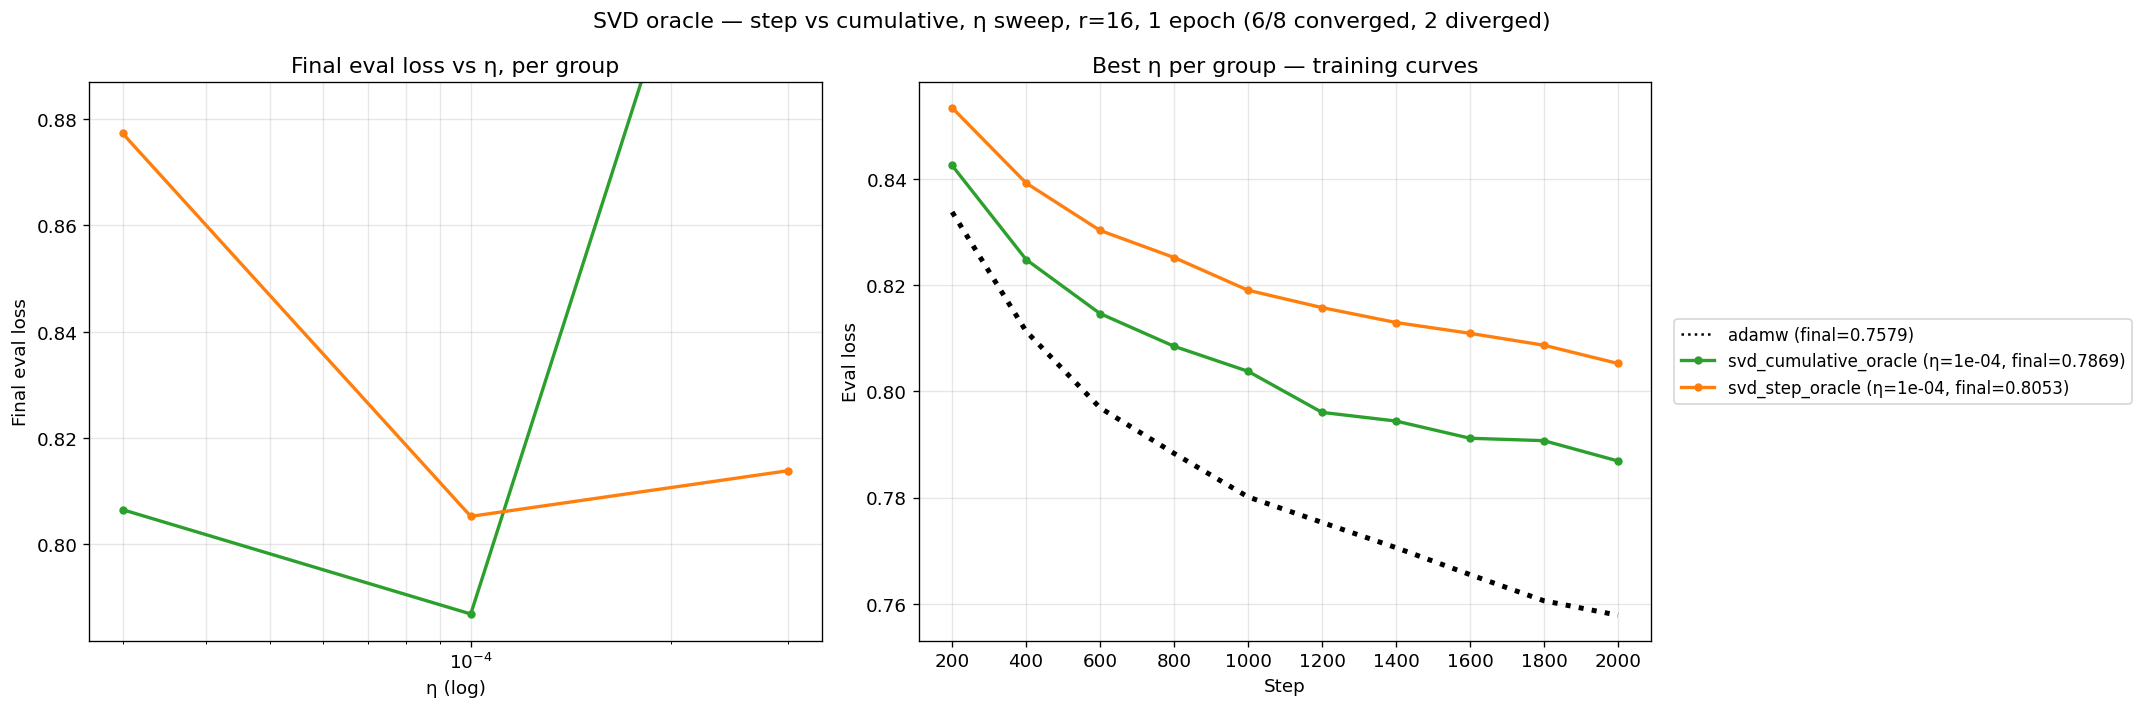

In [12]:
hl, rc = baseline_overlay(all_runs, "adamw")
two_panel_sweep_figure(
    svd_runs,
    group_key_fn=lambda c: c["training_mode"],
    color_map=MODE_COLORS,
    suptitle="SVD oracle — step vs cumulative, η sweep, r=16, 1 epoch",
    hlines=hl,
    ref_curves=rc,
    label_fn=lambda c: f"{c['training_mode']:<25s} η={c['lr']:.0e}",
)
plt.show()

## LoRA+ (η, m) co-sweep — AdamW, r=16, 1 epoch

In [13]:
# Merge AdamW LoRA+ runs across all sweeps that varied (η, m). Filter to
# optimizer="adamw" only. Dedup by (m, η). Earlier groups override later.
LP_SOURCES = (
    "loraplus_lowlr_2k",        # m ∈ {4, 16} × η ∈ {1e-5, 3e-5} (extension)
    "loraplus_2k_1ep",          # m ∈ {1, 4, 16} × η ∈ {1e-4, 3e-4} (original)
    "lr_sweep_2k",              # m=1 × η ∈ {3e-5..1e-3}
    "optim_compare_high_eta_2k",# m=1 × η ∈ {3e-3, 1e-2}
    "new_optimizers_2k",        # m=1 × η ∈ {3e-5..1e-3}
)

lp_runs = merge_runs(
    LP_SOURCES,
    key_fn=lambda c: (float(c.get("lora_plus_multiplier", 1.0)), float(c["lr"])),
    filter_fn=lambda c: c.get("optimizer") == "adamw",
)
print(f"Loaded {len(lp_runs)} AdamW LoRA+ runs (merged)")
for cfg, evs in sorted(lp_runs, key=lambda x: (x[0].get("lora_plus_multiplier", 1), x[0]["lr"])):
    print(f"  m={cfg.get('lora_plus_multiplier', 1):.0f}  η={cfg['lr']:.0e}  "
          f"final={evs[-1]['eval_loss']:.4f}")

Loaded 14 AdamW LoRA+ runs (merged)
  m=1  η=3e-05  final=0.8088
  m=1  η=1e-04  final=0.7816
  m=1  η=3e-04  final=0.7600
  m=1  η=1e-03  final=0.7875
  m=1  η=3e-03  final=1.0223
  m=1  η=1e-02  final=6.9369
  m=4  η=1e-05  final=0.8163
  m=4  η=3e-05  final=0.7905
  m=4  η=1e-04  final=0.7626
  m=4  η=3e-04  final=0.7644
  m=16  η=1e-05  final=0.7940
  m=16  η=3e-05  final=0.7684
  m=16  η=1e-04  final=0.7585
  m=16  η=3e-04  final=0.8128


  [filtered diverged] m=1 η=1e-02              max=9.009 final=6.937


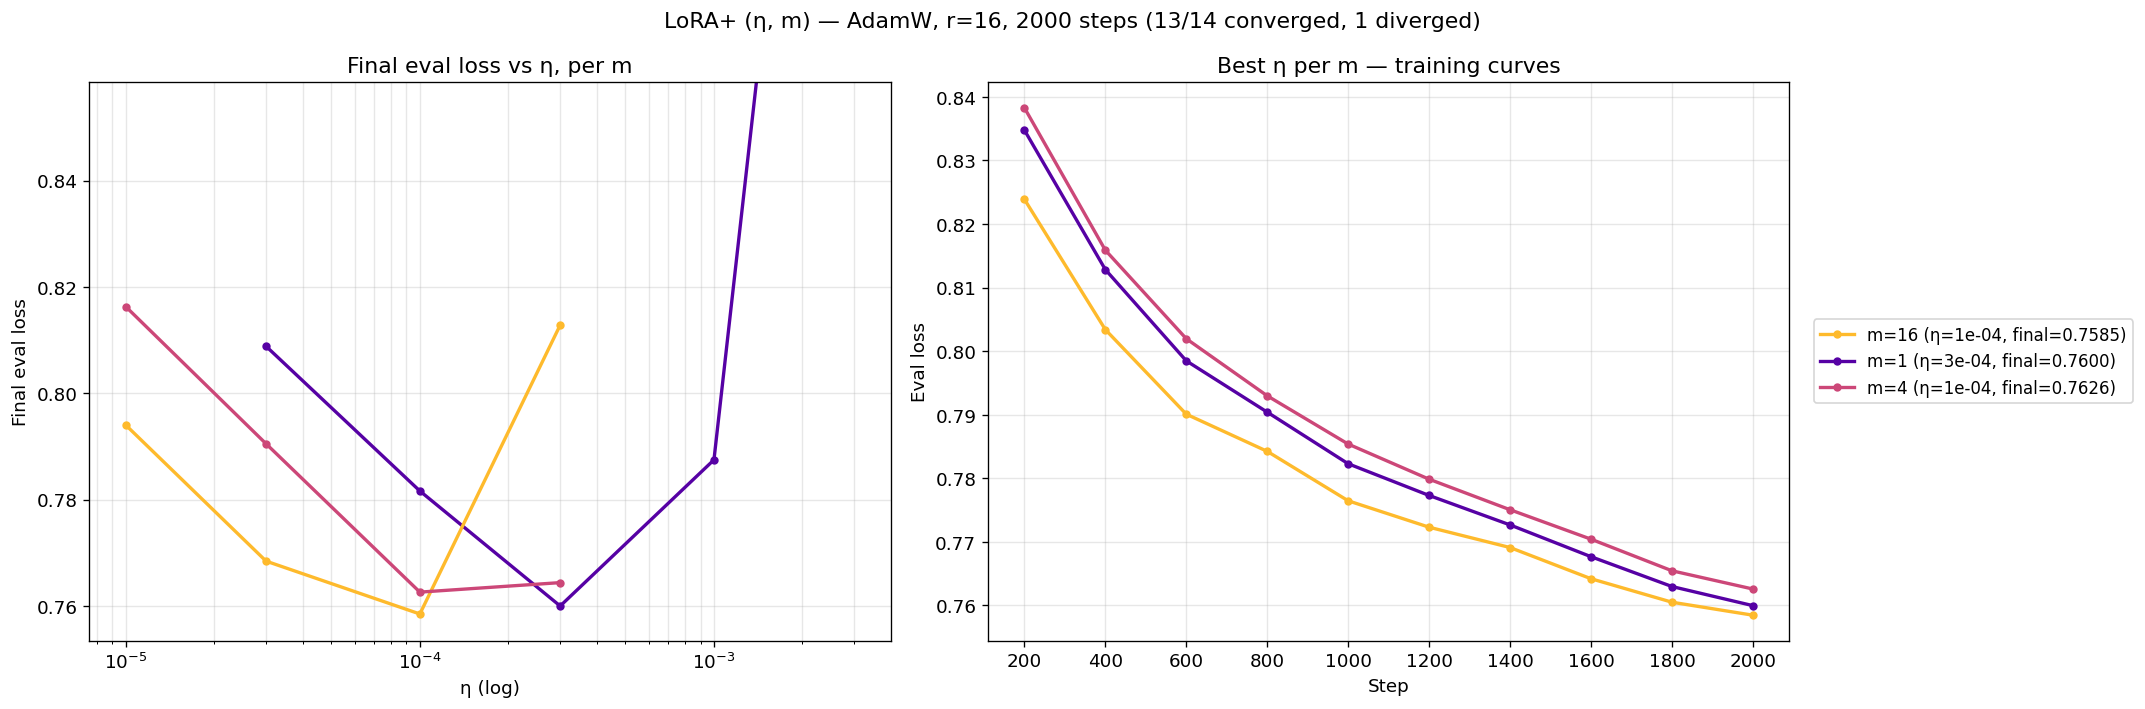

In [14]:
def _lp_group(cfg):
    return f"m={int(round(cfg.get('lora_plus_multiplier', 1.0)))}"

LP_COLOR_MAP = {f"m={m}": c for m, c in M_COLORS.items()}

two_panel_sweep_figure(
    lp_runs,
    group_key_fn=_lp_group,
    color_map=LP_COLOR_MAP,
    suptitle="LoRA+ (η, m) — AdamW, r=16, 2000 steps",
    left_title="Final eval loss vs η, per m",
    right_title="Best η per m — training curves",
    label_fn=lambda c: f"{_lp_group(c)} η={c['lr']:.0e}",
)
plt.show()